In [ ]:
# Auto-reload for development
%load_ext autoreload
%autoreload 2

from nowkit.nowcasting_framework import *
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

## Configuration

In [2]:
# Create configuration
config = NowcastConfig(
    target_variable="gdpc1",
    n_lags=4,
    n_ensemble_models=10,
    lags=list(range(-2, 3)),
    train_start_date="1947-01-01",
    test_start_date="2005-03-01",
    test_end_date="2010-03-01",
    data_path="../data/data_tf.csv",
    metadata_path="../data/meta_data.csv"
)

# MLP hyperparameters
mlp_params = {
    "hidden_layer_sizes": (100, 200),
    "activation": "relu",
    "solver": "adam",
    "alpha": 0.001,
    "learning_rate_init": 0.001,
    "learning_rate": "constant"
}

print(config)

NowcastConfig(data_path='../data/data_tf.csv', metadata_path='../data/meta_data.csv', target_variable='gdpc1', train_start_date='1947-01-01', test_start_date='2005-03-01', test_end_date='2010-03-01', lags=[-2, -1, 0, 1, 2], n_lags=4, quarterly_only=True, n_ensemble_models=10)


## Load and Prepare Data

In [3]:
# Initialize data manager
data_manager = DataManager(config)
data_manager.load_data()
data_manager.prepare_test_data()

print(f"\nData loaded: {data_manager.data.shape}")
print(f"Test data: {data_manager.test_data.shape}")
data_manager.data.tail()

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods

Data loaded: (913, 25)
Test data: (759, 25)


,date,payems,gdpc1,cpiaucsl,dgorder,hsn1f,rsafs,unrate,houst,indpro,...,ir,cpilfesl,pcepilfe,pcepi,permit,tcu,businv,ulcnfb,iq,a261rx1q020sbea
908,2022-09-01,0.001761,0.008012,0.003860,0.002038,-0.134675,-0.001673,-0.054054,-0.028515,0.003825,...,-0.010373,0.005759,0.004644,0.003443,0.014267,0.002561,0.002485,0.005911,-0.009476,0.002056
909,2022-10-01,0.001856,NaN,0.004384,0.007362,0.082290,0.013066,0.057143,-0.021160,-0.000625,...,-0.004193,0.002715,0.002616,0.003729,-0.033248,-0.001789,0.002913,NaN,-0.003827,NaN
910,2022-11-01,0.001716,NaN,0.000963,-0.020892,0.057851,-0.005824,0.000000,-0.004881,-0.002195,...,-0.006316,0.001987,0.001681,0.001043,-0.106481,-0.003271,NaN,NaN,-0.002561,NaN
911,2022-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
912,2023-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Train Models

In [4]:
# Initialize model manager
model_manager = ModelManager(MLPRegressor, mlp_params, config)

# Train models
model_manager.run_backtest(data_manager)

print(f"\nTotal models trained: {len(model_manager.predictions)}")
print(f"Predictions per vintage: {len(model_manager.predictions[config.lags[0]])}")


Running backtest with 10 ensemble model(s)...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed

Total models trained: 5
Predictions per vintage: 21


## Evaluate Performance

In [5]:
# Initialize evaluation manager
evaluator = EvaluationManager()

# Add model results
evaluator.add_model_results(
    model_name="MLP",
    predictions=model_manager.predictions,
    actuals=data_manager.actuals,
    lags=config.lags
)

# Calculate metrics
metrics = evaluator.get_performance_table()
print("\nPerformance by Vintage:")
metrics.round(4)


Performance by Vintage:


Model,Vintage,MLP
0,-2,0.0085
1,-1,0.0069
2,0,0.0066
3,1,0.0061
4,2,0.0061


## Visualize Results

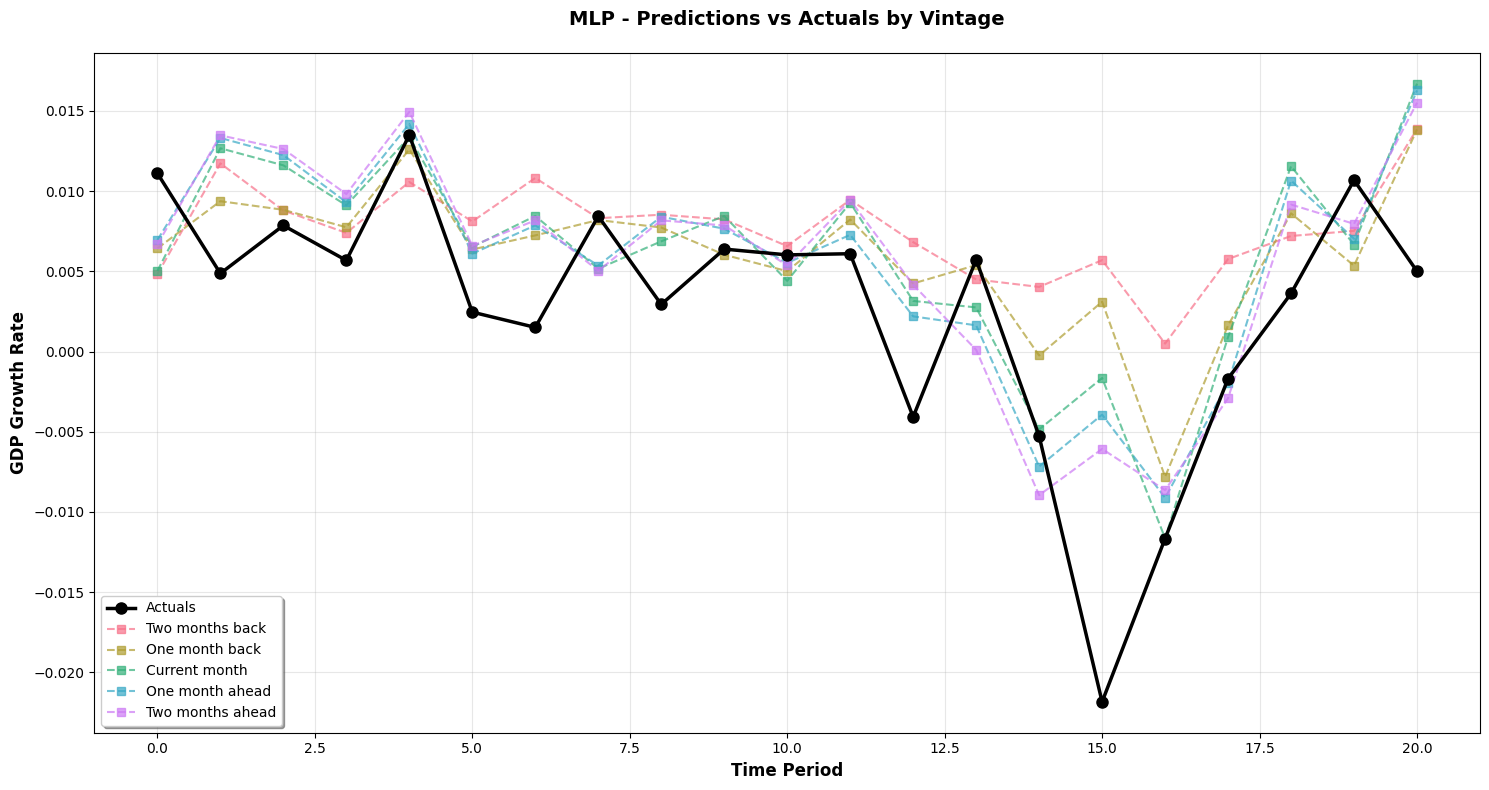

In [6]:
# Initialize visualization manager
viz = VisualizationManager(evaluator)

# Plot predictions
viz.plot_predictions_vs_actuals(model_name="MLP")
plt.show()

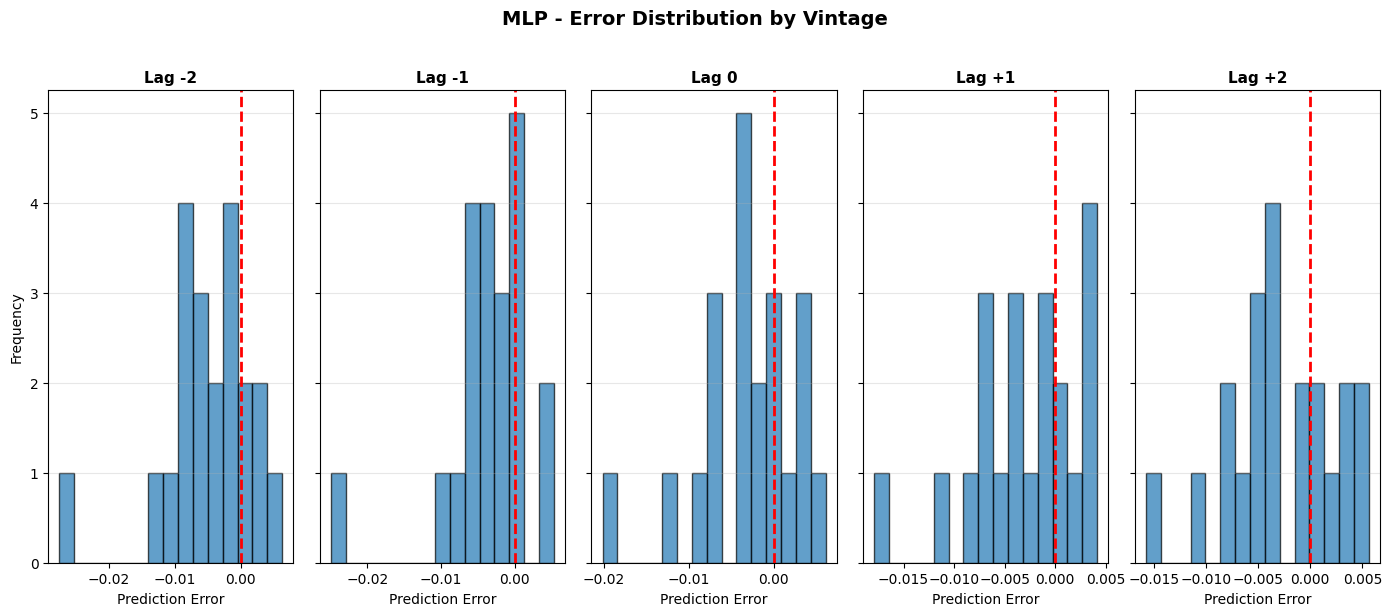

In [7]:
# Plot errors by vintage
viz.plot_error_distribution(model_name="MLP")
plt.show()

## Inference on New Data

In [8]:
# Initialize inference pipeline
inference = InferencePipeline(model_manager, data_manager, config)

# Prepare new data (just for display, pipeline handles it internally)
desired_date = "2010-06-01"
print(f"Target date: {desired_date}")

Target date: 2010-06-01


In [9]:
# Make prediction
result = inference.predict_new_date(desired_date)
print(f"\nPrediction for {desired_date}: {result['prediction']:.4f}")
print(f"Based on {result['n_models']} model(s)")


Prediction for 2010-06-01: 0.0114
Based on 10 model(s)


## Summary

This notebook implements GDP nowcasting using a multilayer perceptron neural network with two hidden layers (100 and 200 neurons). The MLP is trained on flattened time series data with 4 lags of each variable, treating the problem as a standard regression task.

Since MLPs don't handle time series natively, the data is transformed by creating lag features for each variable. The model uses ReLU activation, Adam optimizer, and L2 regularization (alpha=0.001) to prevent overfitting. An ensemble of 10 models is trained to reduce variance from the stochastic training process.

The framework handles data preparation, vintage generation, model training, and evaluation automatically. Performance is assessed across different data vintages to evaluate nowcasting capability under varying information availability.